# Introduction to the `InSituExperiment` class
## Background

<img src="../../demo_data/demo_screenshots/experiment_levels.jpg" height="300"/>

<p>In addition to the sample, cellular, and subcellular levels, a spatial transcriptomics dataset typically includes an experiment level that contains information about clinical and experimental cohorts, conditions, or treatments. Most current computational frameworks lack functionalities to incorporate this level into the analysis. To address this, <code>InSituPy</code> introduces the <code>InSituExperiment</code> class, which manages spatial transcriptomics data and the corresponding metadata of multiple samples simultaneously.</p>


## Structure
<img src="../../demo_data/demo_screenshots/insituexperiment_structure.jpg" height="200"/>

An `InSituExperiment` object consists of multiple `InSituData` objects paired with their corresponding metadata.

In [1]:
## The following code ensures that all functions and init files are reloaded before executions.
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
from insitupy import InSituData, InSituExperiment, CACHE

In [3]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

### Load Xenium data into `InSituData` object

Now the Xenium data can be parsed by providing the data path to the `InSituPy` project folder.

In [4]:
insitupy_project = Path(CACHE / "out/demo_insitupy_project")
xd = InSituData.read(insitupy_project)
xd.load_all(skip="transcripts")
xd

InSituData
Method:		Xenium
Slide ID:	0001879
Sample ID:	Replicate 1
Path:		C:\Users\ge37voy\.cache\InSituPy\out\demo_insitupy_project
Metadata file:	.ispy
    ➤ images
       nuclei:	(25778, 35416)
       CD20:	(25778, 35416)
       HER2:	(25778, 35416)
       HE:	(25778, 35416, 3)
    ➤ cells
       MultiCellData with main layer 'main'
           matrix
               AnnData object with n_obs × n_vars = 156447 × 297
               obs: 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'n_genes_by_counts', 'n_genes', 'leiden', 'cell_type_dc', 'cell_type_dc_sub', 'cell_type_tacco', 'cell_type_publ'
               var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
               uns: 'cell_type_dc_colors', 'cell_type_dc_sub', 'cell_type_dc_sub_colors', 'cell_type_publ_colors', 'cell_type_tacco_colors', 'counts_location', 'leiden', 'leiden_col

### Create `InSituExperiment`

<img src="../../demo_data/demo_screenshots/insituexperiment_generation.jpg" height="250"/>

*Options to generate an InSituExperiment object*

#### Method 1: Manually add `InSituData` objects

In [5]:
exp = InSituExperiment()
exp.add(
    data=xd,
    metadata={
        "slide_id": xd.slide_id,
        "sample_id": xd.sample_id,
        "patient": "A"
    }
    )

In [6]:
exp

InSituExperiment with 1 samples:
           uid  CITAR slide_id    sample_id patient
0     58399b62  ++-++  0001879  Replicate 1       A

In the same way also other datasets can be added. For demonstration purposes, we just add the same dataset again and change the metadata.

In [7]:
exp.add(
    data=xd,
    metadata={
        "slide_id": xd.slide_id,
        "sample_id": xd.sample_id,
        "patient": "A",
        "therapy": "drugB"
    }
    )

In [8]:
exp

InSituExperiment with 2 samples:
           uid  CITAR slide_id    sample_id patient therapy
0     58399b62  ++-++  0001879  Replicate 1       A     NaN
1     cd437dad  ++-++  0001879  Replicate 1       A   drugB

#### Method 2: From config file

As config file either a csv file or an excel file can be used.

Example of a valid configuration file:

| directory         | experiment_name | date       | patient    |
|-------------------|-----------------|------------|------------|
| /path/to/dataset1 | Experiment 1    | 2023-09-01 | Patient A  |
| /path/to/dataset2 | Experiment 2    | 2023-09-02 | Patient B  |

In [9]:
import pandas as pd
from insitupy import CACHE

# Define the data
data = {
    "directory": [f"{CACHE}\\out\\demo_insitupy_project", f"{CACHE}\\out\\demo_insitupy_project"],
    "patient": ["A", "B"],
    "therapy": ["drugA", "drugB"]
}

# Create a DataFrame
config_df = pd.DataFrame(data)

# Write the DataFrame to a CSV file
config_df.to_csv('../../demo_data/demo_experiment/insituexperiment_config.csv', index=False)

In [10]:
exp = InSituExperiment.from_config(config_path="../../demo_data/demo_experiment/insituexperiment_config.csv")

100%|██████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00, 288.41it/s]


In [11]:
exp

InSituExperiment with 2 samples:
           uid  CITAR slide_id    sample_id patient therapy
0     b6369fc5  -----  0001879  Replicate 1       A   drugA
1     b2e39093  -----  0001879  Replicate 1       B   drugB

In [12]:
exp.load_all()

100%|███████████████████████████████████████████████████████████████████████████| 2/2 [00:04<00:00,  2.24s/it]


In [13]:
exp

InSituExperiment with 2 samples:
           uid  CITAR slide_id    sample_id patient therapy
0     b6369fc5  +++++  0001879  Replicate 1       A   drugA
1     b2e39093  +++++  0001879  Replicate 1       B   drugB

#### Method 3: From regions

We can also use regions from an `InSituData` object to split the data into separate datasets and create an `InSituExperiment` from them. This can be used to select the most interesting regions and focus on them for the analysis or to split a TMA dataset into separate datasets for each core.

In [14]:
exp = InSituExperiment.from_regions(
    data=xd, region_key="TMA"
)

A-1
A-2
A-3
B-1
B-2
B-3


In [15]:
exp

InSituExperiment with 6 samples:
           uid  CITAR slide_id    sample_id region_key region_name
0     8d6d341c  ++-++  0001879  Replicate 1        TMA         A-1
1     8a6eebd8  ++-++  0001879  Replicate 1        TMA         A-2
2     82d54661  ++-++  0001879  Replicate 1        TMA         A-3
3     549fa350  ++-++  0001879  Replicate 1        TMA         B-1
4     68c9840c  ++-++  0001879  Replicate 1        TMA         B-2
5     22b42817  ++-++  0001879  Replicate 1        TMA         B-3

In [44]:
# visualize data
exp.show(3)

INFO: New layer '🔬 TestClass (TestKey)' created.


In [23]:
exp.data[3].annotations["a"]

,objectType,geometry,name,color,origin,layer_type
id,,,,,,
b61643d0-110c-496d-a343-4c8e1ce05b1e,annotation,POINT (301.94293 410.90366),a,"[0, 170, 0]",manual,Points
71a2fd6d-75cd-418a-b6a1-2e4dfb50d495,annotation,POINT (513.39151 346.17451),a,"[0, 170, 0]",manual,Points
ce3ad47e-2cb0-4537-95d1-02f46d61f28e,annotation,POINT (663.34739 452.97762),a,"[0, 170, 0]",manual,Points
744672f3-dc8c-46bf-8bf7-beeee1489244,annotation,POINT (690.31787 368.82971),a,"[0, 170, 0]",manual,Points
5e3eb88b-2060-40bc-82ca-e73aa013bc4e,annotation,POINT (259.23789 321.53479),a,"[255, 0, 127]",manual,Points
0b4caef2-8517-4d86-a9b6-05c049f72d30,annotation,POINT (395.54564 432.28484),a,"[255, 0, 127]",manual,Points
488db5bb-fcd0-4c8e-9ed8-6fb2daf9370e,annotation,POINT (864.10354 189.48665),a,"[255, 0, 127]",manual,Points
e1234b02-4833-437f-83aa-491dbf811e11,annotation,POINT (870.49296 152.215),a,"[255, 0, 127]",manual,Points
fcb23966-cd42-4aff-b084-dee4b3305517,annotation,POINT (887.53143 124.52749),a,"[255, 0, 127]",manual,Points


INFO: Added 1 new annotations to existing key 'a'


In [36]:
import napari
viewer = napari.current_viewer()
l = viewer.layers["🔬 TestClass (TestKey)"]

In [37]:
l.name

'🔬 TestClass (TestKey)'

In [38]:
l.properties

{'uid': array(['f0124d10-a5d1-487a-ad16-647d8ffc3a38',
        '615f8762-978c-41cc-9082-6ee1e1d9d810',
        '3e9f6518-6592-48cf-9dac-c6a2f3d41909',
        'd27fbd96-dfbf-4980-bff7-b49fdcd8a848',
        '0f02ba1d-1dd2-451a-bdba-2f44510aafdc',
        '75ac11d0-61c7-471f-a76c-0ea30743ca3b',
        'a8632255-50f9-495f-9987-874cdc3675ca',
        '6ed5fe0f-5d3e-4ff2-a3c2-976d09eec7b8',
        '2c427fb0-24b0-4a8e-919e-58fed347f08d'], dtype=object),
 'type': array(['polygon_exterior', 'polygon_exterior', 'polygon_exterior', 'line',
        'line', 'line', 'polygon_exterior', 'line', 'line'], dtype=object)}

In [39]:
l.shape_type

['polygon',
 'polygon',
 'polygon',
 'path',
 'path',
 'path',
 'polygon',
 'rectangle',
 'rectangle']

In [35]:
exp.data[3].annotations["TestKey"]

,objectType,geometry,name,color,origin,layer_type
id,,,,,,
f0124d10-a5d1-487a-ad16-647d8ffc3a38,annotation,"POLYGON ((204.82802 313.19019, 201.59157 429.7...",TestClass,"[255, 0, 0]",manual,Shapes
615f8762-978c-41cc-9082-6ee1e1d9d810,annotation,"POLYGON ((464.82346 531.11169, 452.95645 534.3...",TestClass,"[255, 0, 0]",manual,Shapes
3e9f6518-6592-48cf-9dac-c6a2f3d41909,annotation,"POLYGON ((723.74011 469.61899, 716.18835 482.5...",TestClass,"[255, 0, 0]",manual,Shapes
6284f78c-c161-4bed-af60-c4512bdcb6b0,annotation,POINT (257.30477 300.51892),TestClass,"[0, 0, 255]",manual,Points
99010fca-365f-44e1-ad72-134106a32ed3,annotation,POINT (463.87771 237.34026),TestClass,"[0, 0, 255]",manual,Points
4a58ed70-aad9-4b9e-9b8d-6a3c18354e78,annotation,POINT (695.29621 357.30874),TestClass,"[0, 0, 255]",manual,Points
96bc02c1-3acb-4bcf-bd2b-13f78201631a,annotation,POINT (492.98249 406.99983),TestClass,"[0, 0, 255]",manual,Points
01f84f4f-7bbf-455e-8bf6-f6d72da61f79,annotation,POINT (571.77836 504.25238),TestClass,"[0, 0, 255]",manual,Points
eca77058-097a-4b14-a983-ebe165b2fe6d,annotation,POINT (382.62923 249.0967),TestClass,"[0, 0, 255]",manual,Points


In [40]:
getattr(exp.data[3], "annotations")

demo2:	1 annotations, 1 class ('Other') 
a:	12 annotations, 1 class ('a') 

## Todos
- add verbose mode for show which then plots things like the actions (save in config class)
- remove unnecessary print statements
- show warning if a new layer is added that exists already in the data (in `add_new_geometries` widget)

In [36]:
exp.data[3].annotations["a"]["name"].contains("a")

AttributeError: 'Series' object has no attribute 'contains'

In [38]:

import pandas as pd

# Example Series
s = pd.Series(['apple', 'banana', 'cherry'])

# Check if 'banana' exists
exists = s.str.contains('anana').any()

print(exists)  # Output: True


True


Example screenshot of data from one of the cropped cores:

<img src="../../demo_data/demo_screenshots/TMA_example.jpg" class="center" height="300"/>

## Work with viewer windows

In [26]:
from insitupy._core._configs import config_manager
import napari

In [ ]:
# visualize data
exp.show(3)

In [27]:
viewer = napari.current_viewer()

In [34]:
viewer.layers['Shapes'].properties['test']

KeyError: 'test'

In [44]:
a = list("ABC")

In [45]:
a += list("ABE")

In [47]:
set(a)

{'A', 'B', 'C', 'E'}

In [40]:
a+= set(list("CDA"))

TypeError: unsupported operand type(s) for +=: 'set' and 'set'

In [37]:
config_manager['1354d792']

In [25]:
config_manager["1354d792"].viewer

AttributeError: 'ViewerConfig' object has no attribute 'viewer'

In [18]:
config_manager.removal_tracker

AttributeError: 'ViewerConfigManager' object has no attribute 'removal_tracker'

In [18]:
from insitupy import sync_geometries

In [46]:
set(list("BC")) ^ set(list("CDB"))

{'D'}

In [39]:
global test
test = "blubb"

In [40]:
test

'blubb'

In [41]:
global test

In [42]:
test

'blubb'

In [18]:
exp.show(0)

In [20]:
exp.data[0].annotations

demo:	4 annotations, 2 classes ('Stroma', 'Tumor cells') 
Demo:	4 annotations, 2 classes ('Stroma', 'Tumor cells') 

In [33]:
exp.data[0].show()

Added 3 new annotations to existing key 'TestKey'
Removed 7 annotations with key TestKey and class TestClass.


# If one adds a new layer of annotations with key and class that exist already, this layer is added without warning. But if I then add new annotations an press sync_geometries, the annotations that are not displayed are removed even though they were not actually removed.

Ways to circumvent this:
1. Only remove annotations that were actually removed. For this one would have to track the removal events and record which annotations were removed.
    - Here is a sample code for keeping track of data events: https://github.com/napari/napari/pull/2992
    - Here is an overarching issue on github: https://github.com/napari/napari/issues/720

2. If a layer is added which already exists, always automatically also display the already existing annotations that one cannot miss that they exist.

In [19]:
import napari
import numpy as np

PTS_COUNT = 0
SHAPES_COUNT = 0

def pts_event_handler(event):
    global PTS_COUNT
    PTS_COUNT += 1
    print(f"POINTS EVENT EMITTED {PTS_COUNT}")


def shapes_event_handler(event):
    global SHAPES_COUNT
    SHAPES_COUNT += 1
    print(f"SHAPES EVENT EMITTED {SHAPES_COUNT}")
    print(event.source.name)
    print(event.action)

viewer = napari.Viewer()

points = np.array([[100, 100], [200, 200], [333, 111]])
size = np.array([10, 20, 20])
pts_layer = viewer.add_points(points, size=size, name='points')

# create a list of polygons
polygons = [
    np.array([[11, 13], [111, 113], [22, 246]]),
    np.array(
        [
            [505, 60],
            [402, 71],
            [383, 42],
            [251, 95],
            [212, 59],
            [131, 137],
            [126, 187],
            [191, 204],
            [171, 248],
            [211, 260],
            [273, 243],
            [264, 225],
            [430, 173],
            [512, 160],
        ]
    ),
    np.array(
        [
            [310, 382],
            [229, 381],
            [209, 401],
            [221, 411],
            [258, 411],
            [300, 412],
            [306, 435],
            [268, 434],
            [265, 454],
            [298, 461],
            [307, 461],
            [307, 507],
            [349, 510],
            [352, 369],
            [330, 366],
            [330, 366],
        ]
    ),
]

# add polygons
shapes_layer = viewer.add_shapes(
    polygons,
    shape_type='polygon',
    edge_width=1,
    edge_color='coral',
    face_color='royalblue',
    name='shapes',
)

pts_layer.events.data.connect(pts_event_handler)
shapes_layer.events.data.connect(shapes_event_handler)


napari.run()

In [ ]:
len(viewer.layers["shapes"].data)

3

SHAPES EVENT EMITTED 1
shapes
adding
SHAPES EVENT EMITTED 2
shapes
added


In [24]:
len(viewer.layers["shapes"].data)

3

In [28]:
config_manager.test = "test"

In [29]:
config_manager.test

'test'

In [26]:
viewer.layers["shapes"].properties

{}

SHAPES EVENT EMITTED 5
shapes
removing
SHAPES EVENT EMITTED 6
shapes
removed


## The code above shows how to track removal events. After a removal event one can then just check which ID is missing from the layer list and then add this to a list of removed items which are then dropped during "Sync Geometries"

In [25]:
sync_geometries()

Added 4 new annotations to existing key 'TestKey'
Removed 1 annotation with key TestKey and class TestClass.


In [26]:
exp.data[0].annotations

demo:	4 annotations, 2 classes ('Stroma', 'Tumor cells') 
Demo:	4 annotations, 2 classes ('Stroma', 'Tumor cells') 
TestKey:	7 annotations, 1 class ('TestClass') 

In [27]:
exp.data[0].show()

In [21]:
config_manager

<ViewerConfigManager with 2 configs: [f20542de, bbc6d1c8]>

In [23]:
c = config_manager["bbc6d1c8"]

In [24]:
c.viewer

AttributeError: 'ViewerConfig' object has no attribute 'viewer'

In [25]:
import napari

In [26]:
viewer = napari.current_viewer()

In [32]:
viewer_id = viewer.title.rsplit("#", 1)[1]
config = config_manager[viewer_id]

In [35]:
napari.__all__

['Viewer',
 '__version__',
 'components',
 'current_viewer',
 'experimental',
 'gui_qt',
 'imshow',
 'layers',
 'notification_manager',
 'qt',
 'run',
 'save_layers',
 'sys_info',
 'types',
 'utils',
 'view_image',
 'view_labels',
 'view_path',
 'view_points',
 'view_shapes',
 'view_surface',
 'view_tracks',
 'view_vectors',
 'viewer']

In [34]:
config.data

InSituData
Method:		Xenium
Slide ID:	0001879
Sample ID:	Replicate 1
Path:		None
Metadata file:	.ispy
    ➤ images
       nuclei:	(4706, 4706)
       CD20:	(4706, 4706)
       HER2:	(4706, 4706)
       HE:	(4706, 4706, 3)
    ➤ cells
       MultiCellData with main layer 'main'
           matrix
               AnnData object with n_obs × n_vars = 3569 × 297
               obs: 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'n_genes_by_counts', 'n_genes', 'leiden', 'cell_type_dc', 'cell_type_dc_sub', 'cell_type_tacco', 'cell_type_publ'
               var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
               uns: 'cell_type_dc_colors', 'cell_type_dc_sub', 'cell_type_dc_sub_colors', 'cell_type_publ_colors', 'cell_type_tacco_colors', 'counts_location', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'umap'
               obsm: '

## Plot overview of metadata and QC metrics

In [18]:
from insitupy.plotting import plot_overview

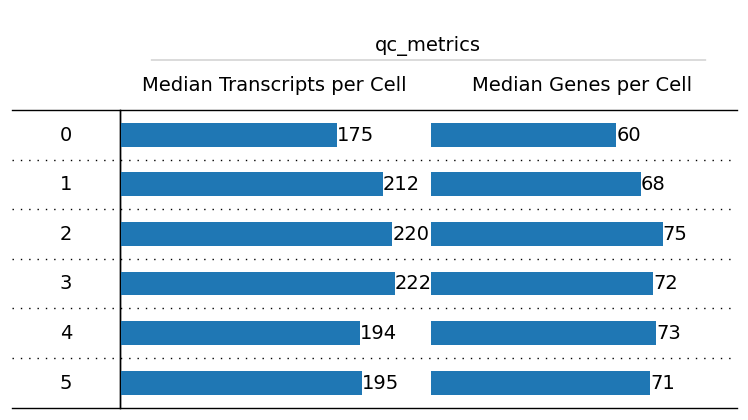

In [19]:
plot_overview(exp)

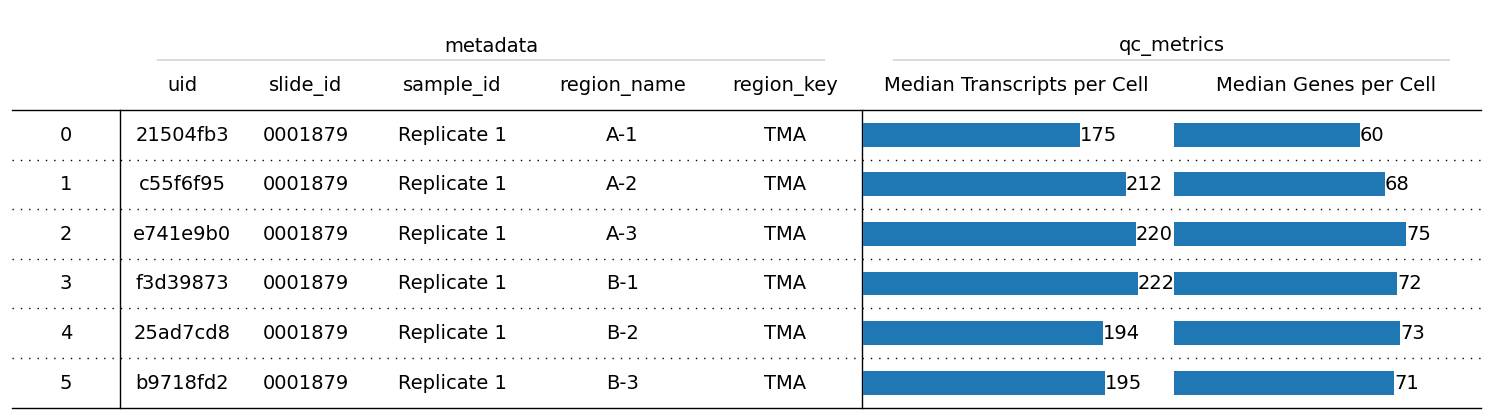

In [20]:
plot_overview(exp, cells_layer="main", colums_to_plot=["uid", "slide_id", "sample_id", "region_name", "region_key"], index=True)

## Iterate through `InSituExperiment` using `.iterdata()` method

In [21]:
for metadata, data in exp.iterdata():
    print(f"Metadata:\n{metadata[:3]}\nData:\n{data}")

Metadata:
uid             21504fb3
slide_id         0001879
sample_id    Replicate 1
Name: 0, dtype: object
Data:
InSituData
Method:		Xenium
Slide ID:	0001879
Sample ID:	Replicate 1
Path:		None
Metadata file:	.ispy
    ➤ images
       nuclei:	(4706, 4706)
       CD20:	(4706, 4706)
       HER2:	(4706, 4706)
       HE:	(4706, 4706, 3)
    ➤ cells
       MultiCellData with main layer 'main'
           matrix
               AnnData object with n_obs × n_vars = 4847 × 297
               obs: 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'n_genes_by_counts', 'n_genes', 'leiden', 'cell_type_dc', 'cell_type_dc_sub', 'cell_type_tacco', 'cell_type_publ'
               var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
               uns: 'cell_type_dc_colors', 'cell_type_dc_sub', 'cell_type_dc_sub_colors', 'cell_type_publ_colors', 'cell_type_tacco

## Add new metadata

In the following section different scenarios for adding new metadata are shown.

In [22]:
exp1 = InSituExperiment.from_regions(
    data=xd, region_key="demo_regions"
)

Region1
Region2
Region3


In [23]:
exp1

InSituExperiment with 3 samples:
           uid  CITAR slide_id    sample_id    region_key region_name
0     3493cd71  ++-++  0001879  Replicate 1  demo_regions     Region1
1     b750995b  ++-++  0001879  Replicate 1  demo_regions     Region2
2     6c7ba21d  ++-++  0001879  Replicate 1  demo_regions     Region3

In [24]:
exp2 = exp1.copy()
exp2.append_metadata(
    new_metadata="../../demo_data/demo_experiment/insituexperiment_new_metadata.csv",
    by="region_name", overwrite=True
)

In [25]:
exp2

InSituExperiment with 3 samples:
           uid  CITAR slide_id    sample_id region_name therapy   organ      test region_key
0     3493cd71  ++-++  0001879  Replicate 1     Region1   drugC   liver  negative       key1
1     b750995b  ++-++  0001879  Replicate 1     Region2   drugD    lung      test       key3
2     6c7ba21d  ++-++  0001879  Replicate 1     Region3   drugE  spleen  positive       key2

In [26]:
exp3 = exp1.copy()
exp3.append_metadata(
    new_metadata="../../demo_data/demo_experiment/insituexperiment_new_metadata.csv",
    by="region_name", overwrite=False
)

In [27]:
exp3

InSituExperiment with 3 samples:
           uid  CITAR slide_id    sample_id    region_key region_name   organ      test therapy
0     3493cd71  ++-++  0001879  Replicate 1  demo_regions     Region1   liver  negative   drugC
1     b750995b  ++-++  0001879  Replicate 1  demo_regions     Region2    lung      test   drugD
2     6c7ba21d  ++-++  0001879  Replicate 1  demo_regions     Region3  spleen  positive   drugE

In [28]:
exp4 = exp1.copy()
exp4.append_metadata(
    new_metadata="../../demo_data/demo_experiment/insituexperiment_new_metadata2.csv",
    by="region_name", overwrite=False
)

In [29]:
exp4

InSituExperiment with 3 samples:
           uid  CITAR slide_id    sample_id    region_key region_name   organ      test therapy
0     3493cd71  ++-++  0001879  Replicate 1  demo_regions     Region1   liver  negative   drugC
1     b750995b  ++-++  0001879  Replicate 1  demo_regions     Region2     NaN       NaN     NaN
2     6c7ba21d  ++-++  0001879  Replicate 1  demo_regions     Region3  spleen  positive   drugE

In [30]:
exp5 = exp1.copy()
exp5.append_metadata(
    new_metadata="../../demo_data/demo_experiment/insituexperiment_new_metadata2.csv",
    by="region_name", overwrite=True
)

In [31]:
exp5

InSituExperiment with 3 samples:
           uid  CITAR slide_id    sample_id region_name therapy   organ      test region_key
0     3493cd71  ++-++  0001879  Replicate 1     Region1   drugC   liver  negative       key1
1     b750995b  ++-++  0001879  Replicate 1     Region2     NaN     NaN       NaN        NaN
2     6c7ba21d  ++-++  0001879  Replicate 1     Region3   drugE  spleen  positive       key2

Concatenate multiple `InSituExperiment` objects

In [32]:
exp

InSituExperiment with 6 samples:
           uid  CITAR slide_id    sample_id region_key region_name
0     21504fb3  ++-++  0001879  Replicate 1        TMA         A-1
1     c55f6f95  ++-++  0001879  Replicate 1        TMA         A-2
2     e741e9b0  ++-++  0001879  Replicate 1        TMA         A-3
3     f3d39873  ++-++  0001879  Replicate 1        TMA         B-1
4     25ad7cd8  ++-++  0001879  Replicate 1        TMA         B-2
5     b9718fd2  ++-++  0001879  Replicate 1        TMA         B-3

In [33]:
exp1

InSituExperiment with 3 samples:
           uid  CITAR slide_id    sample_id    region_key region_name
0     3493cd71  ++-++  0001879  Replicate 1  demo_regions     Region1
1     b750995b  ++-++  0001879  Replicate 1  demo_regions     Region2
2     6c7ba21d  ++-++  0001879  Replicate 1  demo_regions     Region3

In [34]:
exp_concat = InSituExperiment.concat(
    objs={
        "exp_TMA": exp,
        "exp_demo_regions": exp1
    },
    new_col_name="name"
    )

C:\Users\ge37voy\Github\InSituPy\insitupy\_core\insituexperiment.py:249: UserWarning: Observation names are not unique across all datasets.
  warnings.warn("Observation names are not unique across all datasets.")


In [35]:
exp_concat

InSituExperiment with 9 samples:
           uid  CITAR slide_id    sample_id    region_key region_name            name
0     21504fb3  ++-++  0001879  Replicate 1           TMA         A-1         exp_TMA
1     c55f6f95  ++-++  0001879  Replicate 1           TMA         A-2         exp_TMA
2     e741e9b0  ++-++  0001879  Replicate 1           TMA         A-3         exp_TMA
3     f3d39873  ++-++  0001879  Replicate 1           TMA         B-1         exp_TMA
4     25ad7cd8  ++-++  0001879  Replicate 1           TMA         B-2         exp_TMA
5     b9718fd2  ++-++  0001879  Replicate 1           TMA         B-3         exp_TMA
6     3493cd71  ++-++  0001879  Replicate 1  demo_regions     Region1  exp_demo_re...
7     b750995b  ++-++  0001879  Replicate 1  demo_regions     Region2  exp_demo_re...
8     6c7ba21d  ++-++  0001879  Replicate 1  demo_regions     Region3  exp_demo_re...

In [36]:
exp_concat = InSituExperiment.concat(
    objs=[exp, exp1])

C:\Users\ge37voy\Github\InSituPy\insitupy\_core\insituexperiment.py:249: UserWarning: Observation names are not unique across all datasets.
  warnings.warn("Observation names are not unique across all datasets.")


In [37]:
exp_concat

InSituExperiment with 9 samples:
           uid  CITAR slide_id    sample_id    region_key region_name
0     21504fb3  ++-++  0001879  Replicate 1           TMA         A-1
1     c55f6f95  ++-++  0001879  Replicate 1           TMA         A-2
2     e741e9b0  ++-++  0001879  Replicate 1           TMA         A-3
3     f3d39873  ++-++  0001879  Replicate 1           TMA         B-1
4     25ad7cd8  ++-++  0001879  Replicate 1           TMA         B-2
5     b9718fd2  ++-++  0001879  Replicate 1           TMA         B-3
6     3493cd71  ++-++  0001879  Replicate 1  demo_regions     Region1
7     b750995b  ++-++  0001879  Replicate 1  demo_regions     Region2
8     6c7ba21d  ++-++  0001879  Replicate 1  demo_regions     Region3

## Indexing and selection of data within `InSituExperiment`

The `InSituExperiment` class allows simple selection and filtering of data using indices or True/False masks.

### Example 1: Select datasets by index

In [38]:
exp_indexed = exp_concat[:3]

In [39]:
exp_indexed

InSituExperiment with 3 samples:
           uid  CITAR slide_id    sample_id region_key region_name
0     21504fb3  ++-++  0001879  Replicate 1        TMA         A-1
1     c55f6f95  ++-++  0001879  Replicate 1        TMA         A-2
2     e741e9b0  ++-++  0001879  Replicate 1        TMA         A-3

In [53]:
exp_indexed.show(2)

Viewer(camera=Camera(center=(0.0, 286.875, 351.475), zoom=0.28777131886299395, angles=(0.0, 0.0, 90.0), perspective=0.0, mouse_pan=True, mouse_zoom=True), cursor=Cursor(position=(1.0, 1.0), scaled=True, size=1, style=<CursorStyle.STANDARD: 'standard'>), dims=Dims(ndim=2, ndisplay=2, last_used=0, range=((0.0, 573.9625, 0.2125), (0.0, 703.1625, 0.2125)), current_step=(1350, 1654), order=(0, 1), axis_labels=('0', '1')), grid=GridCanvas(stride=1, shape=(-1, -1), enabled=False), layers=[<Image layer 'nuclei' at 0x235aa8b1790>, <Image layer 'CD20' at 0x235e53fa6d0>, <Image layer 'HER2' at 0x235e5414850>, <Image layer 'HE' at 0x235e7cc3430>], help='use <2> for transform', status='Ready', tooltip=Tooltip(visible=False, text=''), theme='dark', title='0001879: Replicate 1', mouse_over_canvas=False, mouse_move_callbacks=[], mouse_drag_callbacks=[], mouse_double_click_callbacks=[], mouse_wheel_callbacks=[<function dims_scroll at 0x000002350FA8B8B0>], _persisted_mouse_event={}, _mouse_drag_gen={}, 

Also a list of indices can be used for this.

In [44]:
exp_concat[[0,1,4]]

InSituExperiment with 3 samples:
           uid  CITAR slide_id    sample_id region_key region_name
0     21504fb3  ++-++  0001879  Replicate 1        TMA         A-1
1     c55f6f95  ++-++  0001879  Replicate 1        TMA         A-2
2     25ad7cd8  ++-++  0001879  Replicate 1        TMA         B-2

### Example 2: Select only datasets with a "1" in the region name using a mask

In [ ]:
filtering_mask = exp_concat.metadata["region_name"].str.contains("1", na=False) # NaN values are filled with False
exp_filtered = exp_concat[filtering_mask]

### Example 3: Query data

The `.query()` function can be used to the [`pandas.DataFrame.query`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.query.html) function.

In [41]:
exp_concat.query(
    criteria="region_key == 'demo_regions'"
)

InSituExperiment with 3 samples:
           uid  CITAR slide_id    sample_id    region_key region_name
0     3493cd71  ++-++  0001879  Replicate 1  demo_regions     Region1
1     b750995b  ++-++  0001879  Replicate 1  demo_regions     Region2
2     6c7ba21d  ++-++  0001879  Replicate 1  demo_regions     Region3

## Save `InSituExperiment`

In [67]:
exp_concat.saveas(CACHE / "out/test_insituexperiment", overwrite=True)

100%|██████████| 5/5 [00:12<00:00,  2.50s/it]


## Reload `InSituExperiment`

In [68]:
exp_reloaded = InSituExperiment.read(CACHE / "out/test_insituexperiment/")

100%|██████████| 5/5 [00:00<00:00, 1249.35it/s]


In [69]:
exp_reloaded.load_all()

100%|██████████| 5/5 [00:00<00:00,  8.85it/s]


In [70]:
exp_reloaded

InSituExperiment with 5 samples:
           uid  CITAR  slide_id    sample_id patient therapy    region_key region_name
0     fbc3579c  -----      1879  Replicate 1       A   drugA           NaN         NaN
1     7168bb60  -----      1879  Replicate 1       B   drugB           NaN         NaN
2     e41835c6  ++-++      1879  Replicate 1     NaN     NaN  demo_regions     Region1
3     b18057d7  ++-++      1879  Replicate 1     NaN     NaN  demo_regions     Region2
4     4668ae9b  ++-++      1879  Replicate 1     NaN     NaN  demo_regions     Region3

In [71]:
exp_reloaded.show(2)

Viewer(camera=Camera(center=(0.0, 286.875, 351.475), zoom=0.28777131886299395, angles=(0.0, 0.0, 90.0), perspective=0.0, mouse_pan=True, mouse_zoom=True), cursor=Cursor(position=(1.0, 1.0), scaled=True, size=1, style=<CursorStyle.STANDARD: 'standard'>), dims=Dims(ndim=2, ndisplay=2, last_used=0, range=((0.0, 573.9625, 0.2125), (0.0, 703.1625, 0.2125)), current_step=(1350, 1654), order=(0, 1), axis_labels=('0', '1')), grid=GridCanvas(stride=1, shape=(-1, -1), enabled=False), layers=[<Image layer 'nuclei' at 0x235f9e93760>, <Image layer 'CD20' at 0x235fa107340>, <Image layer 'HER2' at 0x235fa2d9970>, <Image layer 'HE' at 0x236000ed8e0>], help='use <2> for transform', status='Ready', tooltip=Tooltip(visible=False, text=''), theme='dark', title='0001879: Replicate 1', mouse_over_canvas=False, mouse_move_callbacks=[], mouse_drag_callbacks=[], mouse_double_click_callbacks=[], mouse_wheel_callbacks=[<function dims_scroll at 0x000002350FA8B8B0>], _persisted_mouse_event={}, _mouse_drag_gen={}, 